# M2 – Exploration des données

**Responsable :** Toky

Ce notebook explore les données nettoyées de `data/processed/` (jeu étendu) : profil des clients, ventes, produits, canaux, évolution dans le temps et campagnes. Chaque graphique est exporté dans `figures/` avec un nom commençant par `m2_`, pour être réutilisé dans le rapport et le PowerPoint.

Les règles de nettoyage et la méthode de génération du jeu étendu sont décrites dans `docs/regles_donnees.md`.

## 0. Préparation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

# Racine du dépôt, quel que soit le dossier d'où le notebook est lancé
RACINE = Path.cwd()
while not (RACINE / "data" / "processed").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
DATA = RACINE / "data" / "processed"
FIGURES = RACINE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5.5), "figure.dpi": 110, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLEU, ORANGE = "#4C72B0", "#DD8452"
PALETTE = sns.color_palette("colorblind")

def sauver(fig, nom):
    fig.savefig(FIGURES / f"m2_{nom}.png", dpi=150, bbox_inches="tight")

euros = mticker.FuncFormatter(lambda x, p: f"{x:,.0f}".replace(",", " "))

Matplotlib is building the font cache; this may take a moment.


In [2]:
ventes = pd.read_csv(DATA / "ventes_fusionnees.csv", parse_dates=["Date", "Join_Date"])
clients = pd.read_csv(DATA / "clients_agreges.csv",
                      parse_dates=["Join_Date", "Premier_Achat", "Dernier_Achat"])
campagnes = pd.read_csv(DATA / "marketing_nettoye.csv", parse_dates=["Start_Date", "End_Date"])
acheteurs = clients[clients["Nb_Achats"] > 0]

## 1. Vue d'ensemble des données

In [3]:
apercu = pd.DataFrame({
    "Lignes": [len(ventes), len(clients), len(campagnes)],
    "Colonnes": [ventes.shape[1], clients.shape[1], campagnes.shape[1]],
    "Valeurs manquantes": [ventes.isna().sum().sum(), clients.isna().sum().sum(),
                           campagnes.isna().sum().sum()],
}, index=["ventes_fusionnees", "clients_agreges", "marketing_nettoye"])
apercu

,Lignes,Colonnes,Valeurs manquantes
ventes_fusionnees,5337,15,0
clients_agreges,805,19,316
marketing_nettoye,50,8,0


In [4]:
print(f"Période des ventes : du {ventes['Date'].min().date()} au {ventes['Date'].max().date()}")
print(f"Chiffre d'affaires total : {ventes['Sale_Price'].sum():,.0f}".replace(",", " "))
print(f"Panier moyen : {ventes['Sale_Price'].mean():.2f}")
print(f"Clients sans achat : {(clients['Nb_Achats'] == 0).sum()}")
print("Valeurs manquantes de clients_agreges :")
print(clients.isna().sum()[clients.isna().sum() > 0])

Période des ventes : du 2023-01-01 au 2024-12-31
Chiffre d'affaires total : 484 673
Panier moyen : 90.81
Clients sans achat : 79
Valeurs manquantes de clients_agreges :
Premier_Achat    79
Dernier_Achat    79
Recence_Jours    79
Canal_Prefere    79
dtype: int64


**Commentaire.** Les valeurs manquantes de `clients_agreges` concernent uniquement les 79 clients qui n'ont jamais acheté (dates d'achat et récence vides), conformément à la règle 3. Il n'y a aucune autre donnée manquante. Les ventes couvrent deux années complètes, ce qui permet d'étudier la saisonnalité et le churn.

In [5]:
ventes[["Price", "Quantity", "Sale_Price"]].describe().round(2)

,Price,Quantity,Sale_Price
count,5337.00,5337.00,5337.00
mean,71.22,1.39,90.81
std,55.72,0.65,73.34
min,15.00,1.00,15.00
25%,25.00,1.00,35.00
50%,45.00,1.00,65.00
75%,120.00,2.00,130.00
max,180.00,6.00,720.00


## 2. Profil des clients

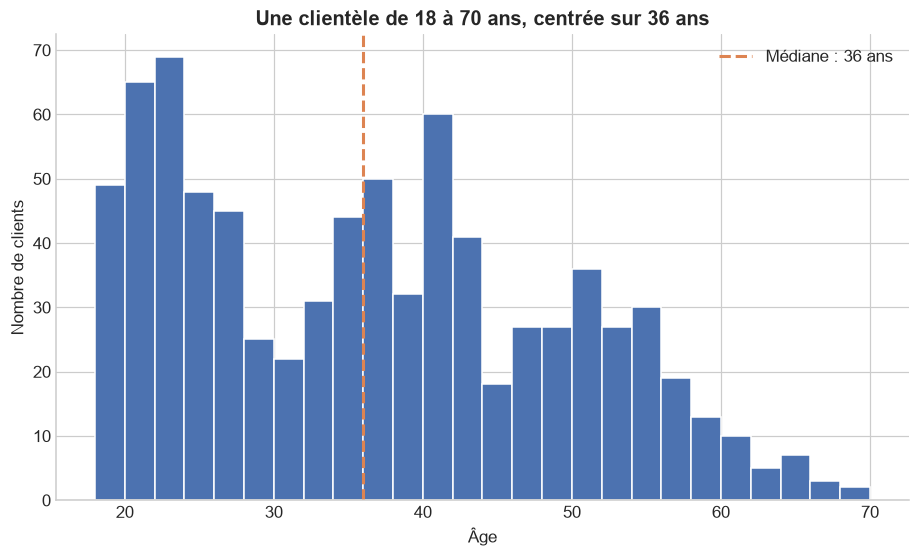

In [6]:
fig, ax = plt.subplots()
ax.hist(clients["Age"], bins=range(18, 72, 2), color=BLEU, edgecolor="white")
ax.axvline(clients["Age"].median(), color=ORANGE, ls="--", lw=2,
           label=f"Médiane : {clients['Age'].median():.0f} ans")
ax.set_title("Une clientèle de 18 à 70 ans, centrée sur 36 ans")
ax.set_xlabel("Âge"); ax.set_ylabel("Nombre de clients"); ax.legend()
sauver(fig, "01_age_clients"); plt.show()

**Commentaire.** La clientèle couvre toutes les tranches d'âge, de 18 à 70 ans, avec une médiane de 36 ans. La distribution n'est pas homogène : on observe une forte concentration de clients de moins de 30 ans, puis des effectifs plus étalés au-delà. Cette diversité d'âge est un premier indice qu'il existe plusieurs types de clients, ce que la segmentation (M3) devra confirmer.

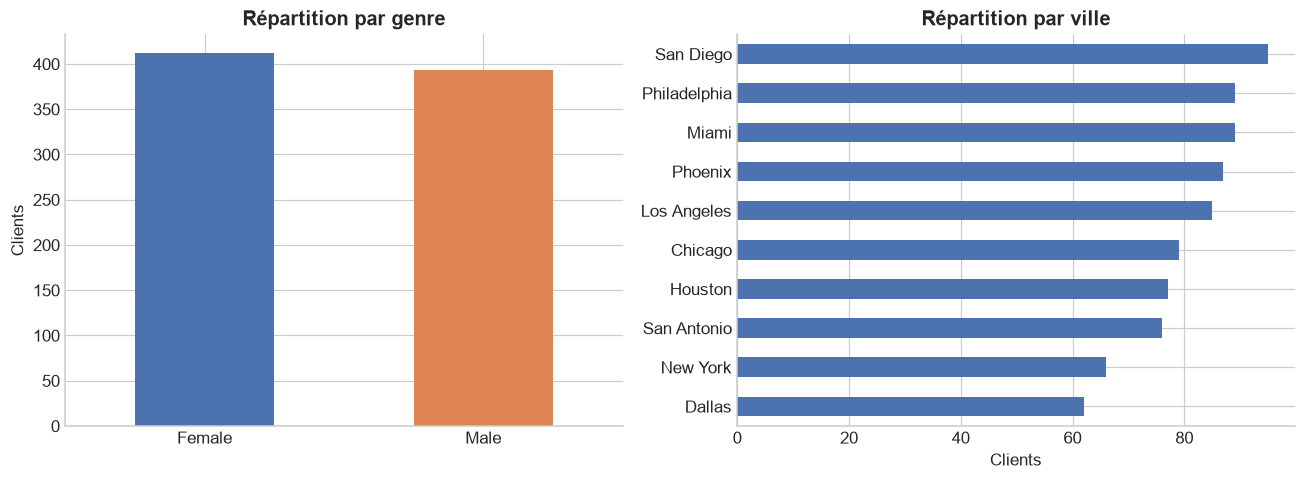

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
clients["Gender"].value_counts().plot.bar(ax=axes[0], color=[BLEU, ORANGE], rot=0)
axes[0].set_title("Répartition par genre"); axes[0].set_xlabel(""); axes[0].set_ylabel("Clients")
clients["Location"].value_counts().sort_values().plot.barh(ax=axes[1], color=BLEU)
axes[1].set_title("Répartition par ville"); axes[1].set_xlabel("Clients"); axes[1].set_ylabel("")
fig.tight_layout(); sauver(fig, "02_genre_ville"); plt.show()

**Commentaire.** Les clients sont répartis de façon équilibrée entre femmes et hommes et entre les 10 villes. Ni le genre ni la ville ne semblent donc être des critères forts pour différencier les clients : les variables de comportement d'achat (fréquence, montant, canal, catégories) seront plus utiles pour la segmentation.

## 3. Comportement d'achat

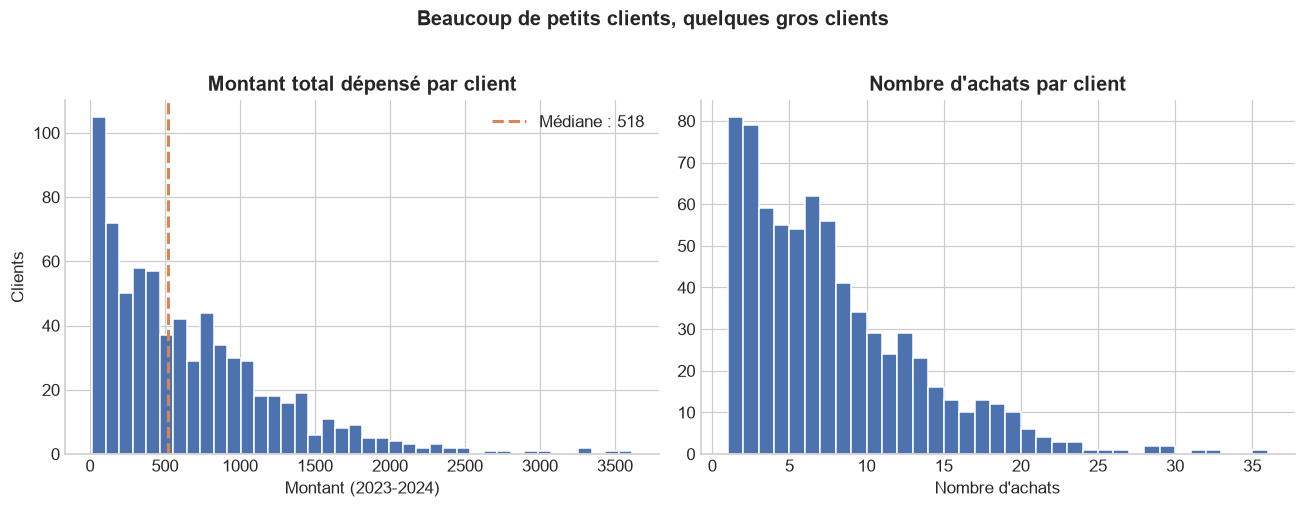

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(acheteurs["Montant_Total"], bins=40, color=BLEU, edgecolor="white")
axes[0].axvline(acheteurs["Montant_Total"].median(), color=ORANGE, ls="--", lw=2,
                label=f"Médiane : {acheteurs['Montant_Total'].median():.0f}")
axes[0].set_title("Montant total dépensé par client"); axes[0].set_xlabel("Montant (2023-2024)")
axes[0].set_ylabel("Clients"); axes[0].legend()
axes[1].hist(acheteurs["Nb_Achats"], bins=range(1, 37), color=BLEU, edgecolor="white")
axes[1].set_title("Nombre d'achats par client"); axes[1].set_xlabel("Nombre d'achats")
fig.suptitle("Beaucoup de petits clients, quelques gros clients", fontweight="bold", y=1.02)
fig.tight_layout(); sauver(fig, "03_montant_frequence"); plt.show()

**Commentaire.** Les deux distributions sont très asymétriques : la moitié des clients ont dépensé moins d'environ 520 sur deux ans, mais une minorité dépasse 1 500, jusqu'à plus de 3 600. De même, la plupart des clients font moins de 10 achats, alors que quelques-uns en font plus de 30. Ces écarts justifient une stratégie différenciée : les gros clients sont à fidéliser en priorité. Pour le K-means, ces variables devront être normalisées, voire transformées (logarithme), pour que les valeurs extrêmes ne dominent pas.

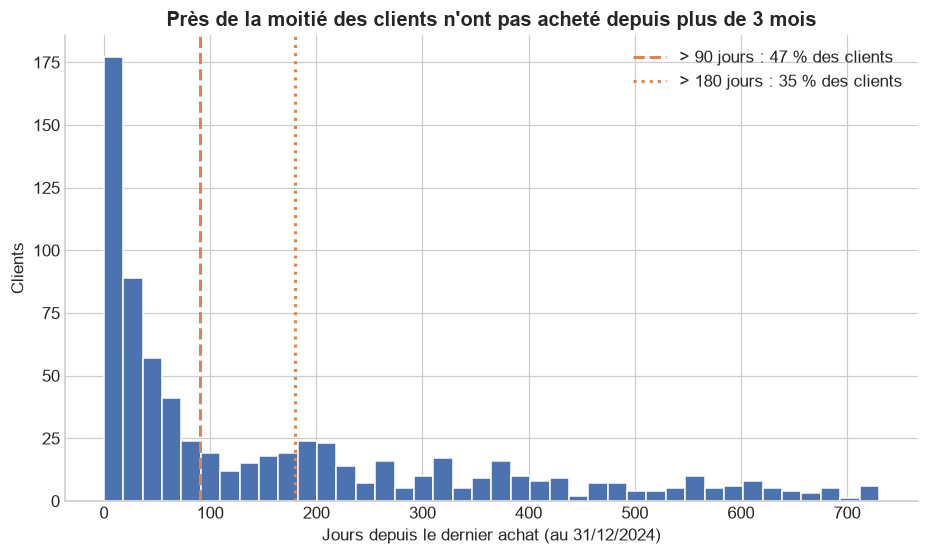

In [9]:
fig, ax = plt.subplots()
ax.hist(acheteurs["Recence_Jours"], bins=40, color=BLEU, edgecolor="white")
for seuil, style in [(90, "--"), (180, ":")]:
    part = (acheteurs["Recence_Jours"] > seuil).mean() * 100
    ax.axvline(seuil, color=ORANGE, ls=style, lw=2, label=f"> {seuil} jours : {part:.0f} % des clients")
ax.set_title("Près de la moitié des clients n'ont pas acheté depuis plus de 3 mois")
ax.set_xlabel("Jours depuis le dernier achat (au 31/12/2024)"); ax.set_ylabel("Clients"); ax.legend()
sauver(fig, "04_recence"); plt.show()

**Commentaire.** Beaucoup de clients ont acheté récemment, mais près de la moitié des acheteurs n'ont plus rien acheté depuis plus de 3 mois, et plus d'un tiers depuis plus de 6 mois. Ces clients sont potentiellement perdus : c'est le phénomène que le modèle de churn (M6) cherchera à prédire, et que la stratégie (M7) devra traiter avec des actions de réactivation.

## 4. Produits et catégories

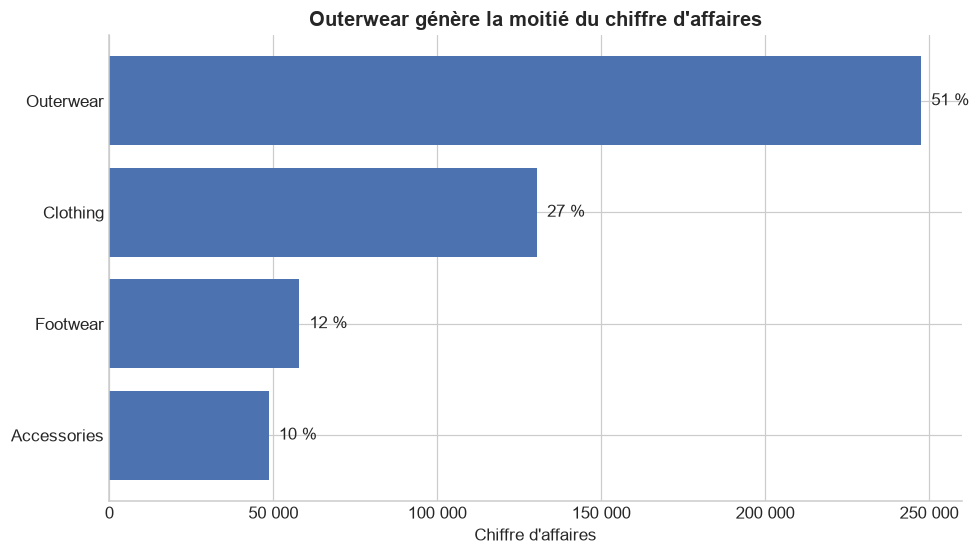

In [10]:
ca_cat = ventes.groupby("Category")["Sale_Price"].sum().sort_values()
fig, ax = plt.subplots()
barres = ax.barh(ca_cat.index, ca_cat.values, color=BLEU)
for b, v in zip(barres, ca_cat.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f"  {v / ca_cat.sum() * 100:.0f} %", va="center")
ax.set_title("Outerwear génère la moitié du chiffre d'affaires")
ax.set_xlabel("Chiffre d'affaires"); ax.xaxis.set_major_formatter(euros)
sauver(fig, "05_ca_categorie"); plt.show()

In [11]:
par_cat = ventes.groupby("Category").agg(Ventes=("Sale_ID", "count"),
                                         CA=("Sale_Price", "sum"),
                                         Panier_Moyen=("Sale_Price", "mean")).round(1)
par_cat.sort_values("CA", ascending=False)

,Ventes,CA,Panier_Moyen
Category,,,
Outerwear,1361,247610.0,181.9
Clothing,1987,130445.0,65.6
Footwear,735,57970.0,78.9
Accessories,1254,48648.0,38.8


**Commentaire.** Outerwear (manteaux, parkas, vestes) représente environ la moitié du chiffre d'affaires alors qu'elle ne compte qu'environ un quart des ventes : ce sont des produits chers, avec un panier moyen élevé. À l'inverse, Clothing est la catégorie la plus vendue en nombre, mais avec des prix plus bas. Accessories et Footwear pèsent peu en chiffre d'affaires. Pour la stratégie, Outerwear est la catégorie à forte valeur, et Clothing celle qui fait venir les clients.

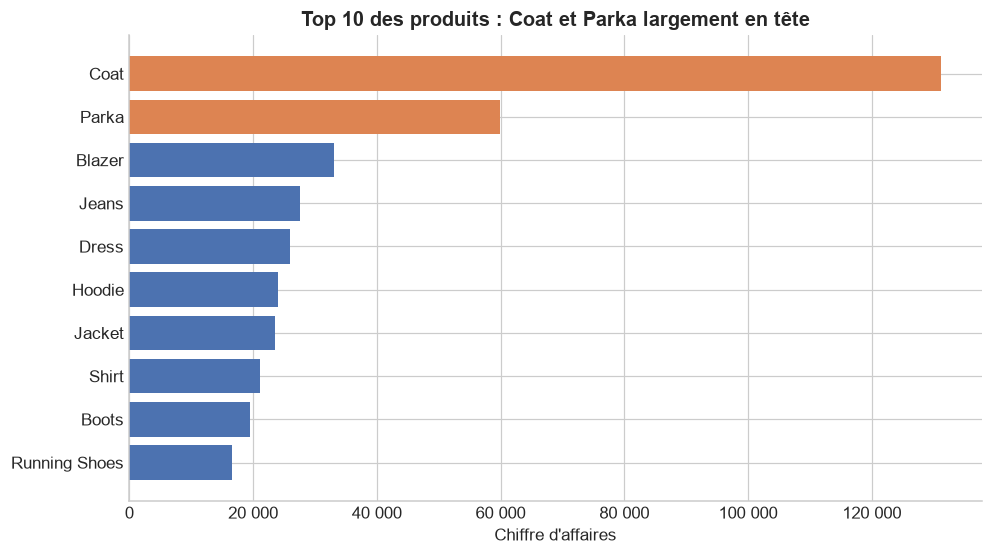

In [12]:
top = ventes.groupby("Product_Name")["Sale_Price"].sum().sort_values().tail(10)
fig, ax = plt.subplots()
ax.barh(top.index, top.values, color=[ORANGE if i >= 8 else BLEU for i in range(10)])
ax.set_title("Top 10 des produits : Coat et Parka largement en tête")
ax.set_xlabel("Chiffre d'affaires"); ax.xaxis.set_major_formatter(euros)
sauver(fig, "06_top_produits"); plt.show()

**Commentaire.** Le Coat à lui seul génère plus de 130 000 de chiffre d'affaires, soit plus du quart du total, et la Parka arrive loin derrière en deuxième position. Le chiffre d'affaires dépend donc fortement de quelques produits chers, ce qui représente à la fois une force et un risque pour l'entreprise.

## 5. Canaux de vente

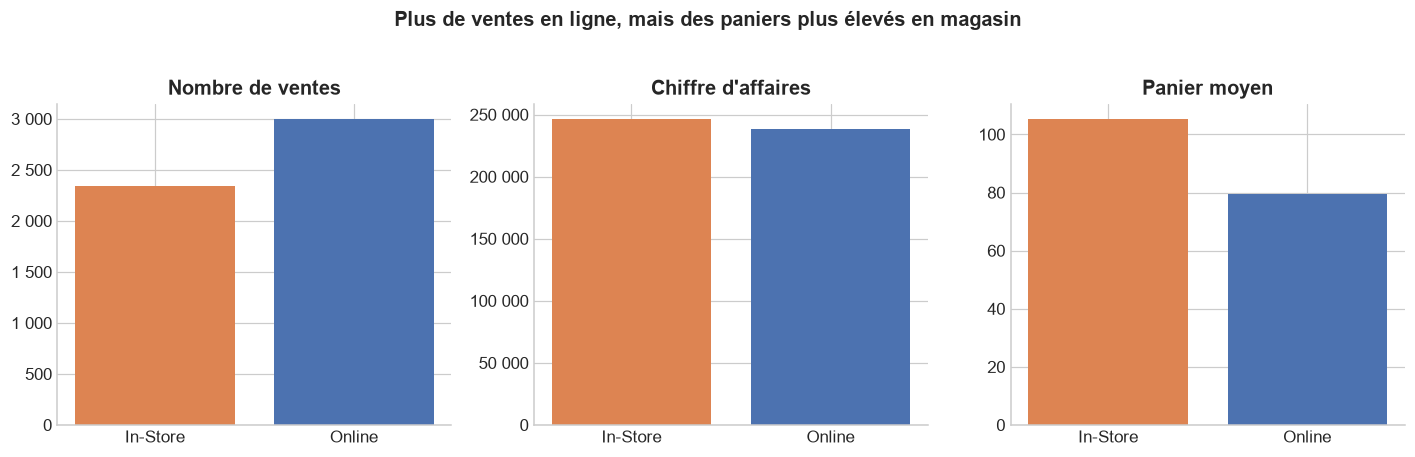

,Ventes,CA,Panier_Moyen
Channel,,,
In-Store,2340,246301.5,105.3
Online,2997,238371.5,79.5


In [13]:
par_canal = ventes.groupby("Channel").agg(Ventes=("Sale_ID", "count"),
                                          CA=("Sale_Price", "sum"),
                                          Panier_Moyen=("Sale_Price", "mean"))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, titre in zip(axes, ["Ventes", "CA", "Panier_Moyen"],
                          ["Nombre de ventes", "Chiffre d'affaires", "Panier moyen"]):
    ax.bar(par_canal.index, par_canal[col], color=[ORANGE, BLEU])
    ax.set_title(titre); ax.yaxis.set_major_formatter(euros)
fig.suptitle("Plus de ventes en ligne, mais des paniers plus élevés en magasin", fontweight="bold", y=1.03)
fig.tight_layout(); sauver(fig, "07_canaux"); plt.show()
par_canal.round(1)

**Commentaire.** Le canal Online réalise plus de ventes que le magasin, mais avec un panier moyen plus faible (environ 80 contre 105). Au final, les deux canaux génèrent un chiffre d'affaires comparable. Le magasin reste donc aussi important que le canal en ligne pour l'entreprise.

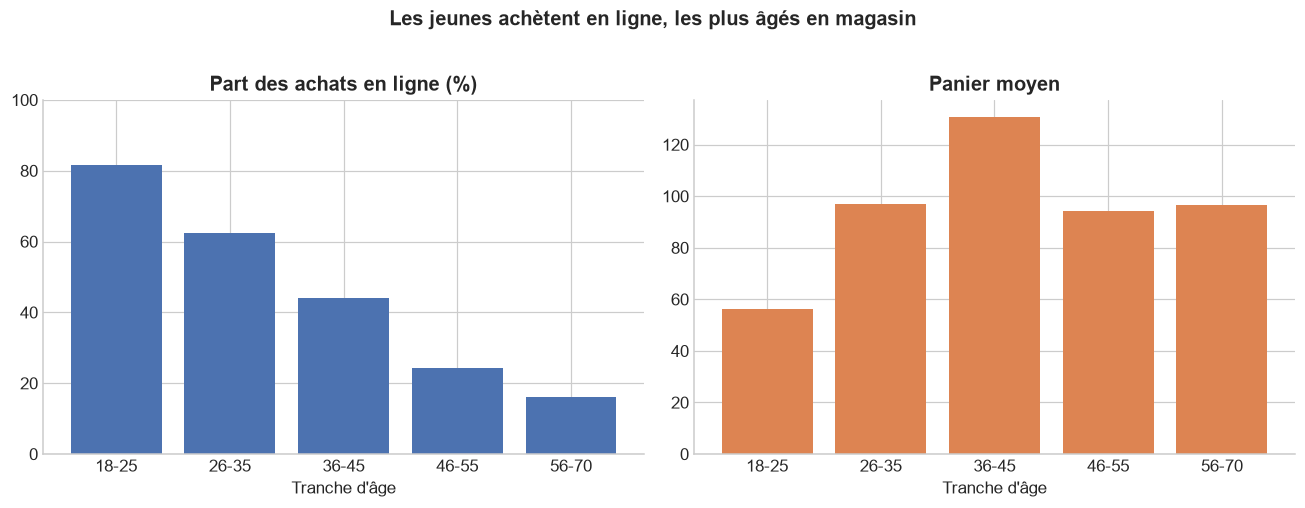

,Part_Online,Panier_Moyen,Nb_Achats
Age,,,
18-25,81.6,56.1,9.8
26-35,62.5,96.9,5.9
36-45,44.1,130.8,5.6
46-55,24.4,94.3,6.8
56-70,16.0,96.7,8.2


In [14]:
tranches = pd.cut(acheteurs["Age"], [17, 25, 35, 45, 55, 70],
                  labels=["18-25", "26-35", "36-45", "46-55", "56-70"])
par_age = acheteurs.groupby(tranches, observed=True)[["Part_Online", "Panier_Moyen", "Nb_Achats"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(par_age.index.astype(str), par_age["Part_Online"], color=BLEU)
axes[0].set_title("Part des achats en ligne (%)"); axes[0].set_ylim(0, 100)
axes[1].bar(par_age.index.astype(str), par_age["Panier_Moyen"], color=ORANGE)
axes[1].set_title("Panier moyen")
for ax in axes: ax.set_xlabel("Tranche d'âge")
fig.suptitle("Les jeunes achètent en ligne, les plus âgés en magasin", fontweight="bold", y=1.02)
fig.tight_layout(); sauver(fig, "08_age_canal_panier"); plt.show()
par_age.round(1)

**Commentaire.** L'âge est fortement lié au canal d'achat : plus de 80 % des achats des 18-25 ans se font en ligne, contre moins de 20 % pour les 56-70 ans. Le panier moyen suit une autre logique : il est le plus faible chez les 18-25 ans et le plus élevé chez les 36-45 ans. C'est une information clé pour la stratégie (M7) : le choix du canal de communication doit dépendre de l'âge du segment visé.

## 6. Évolution dans le temps

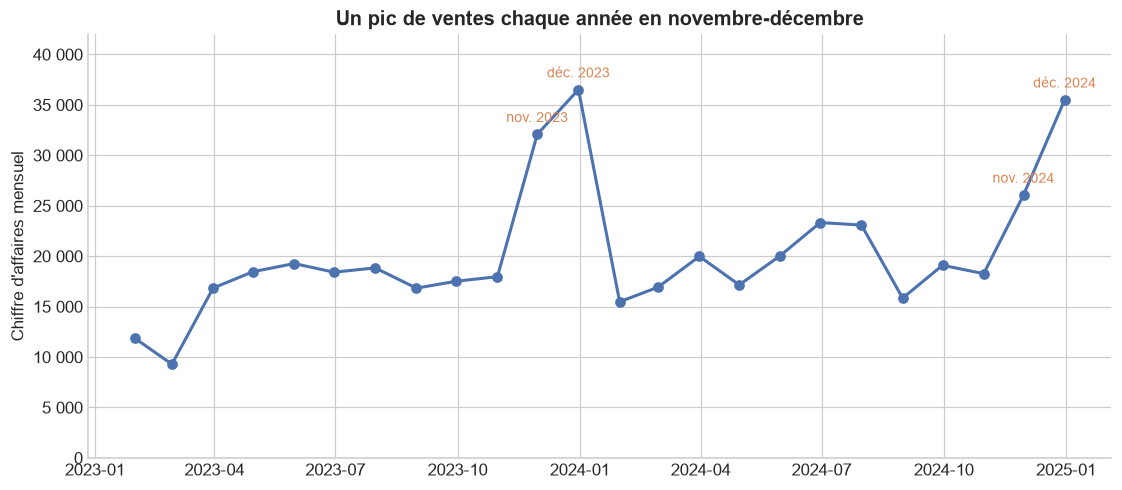

Date
2023    233869.0
2024    250804.0
Name: Sale_Price, dtype: float64


In [15]:
MOIS = {11: "nov.", 12: "déc."}
mensuel = ventes.set_index("Date")["Sale_Price"].resample("ME").sum()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mensuel.index, mensuel.values, color=BLEU, lw=2, marker="o")
for d, v in mensuel[mensuel.index.month.isin([11, 12])].items():
    ax.annotate(f"{MOIS[d.month]} {d.year}", (d, v), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, color=ORANGE)
ax.set_title("Un pic de ventes chaque année en novembre-décembre")
ax.set_ylabel("Chiffre d'affaires mensuel"); ax.yaxis.set_major_formatter(euros)
ax.set_ylim(0, mensuel.max() * 1.15)
sauver(fig, "09_evolution_mensuelle"); plt.show()
print(ventes.groupby(ventes["Date"].dt.year)["Sale_Price"].sum().round(0))

**Commentaire.** Le chiffre d'affaires mensuel est assez stable pendant l'année, puis double presque en novembre et décembre, les deux années. C'est une saisonnalité marquée (fêtes de fin d'année, achats de manteaux pour l'hiver). Le chiffre d'affaires progresse légèrement entre 2023 et 2024. Pour la stratégie (M7), les campagnes les plus importantes devraient être concentrées avant et pendant cette période.

## 7. Relations entre les variables clients

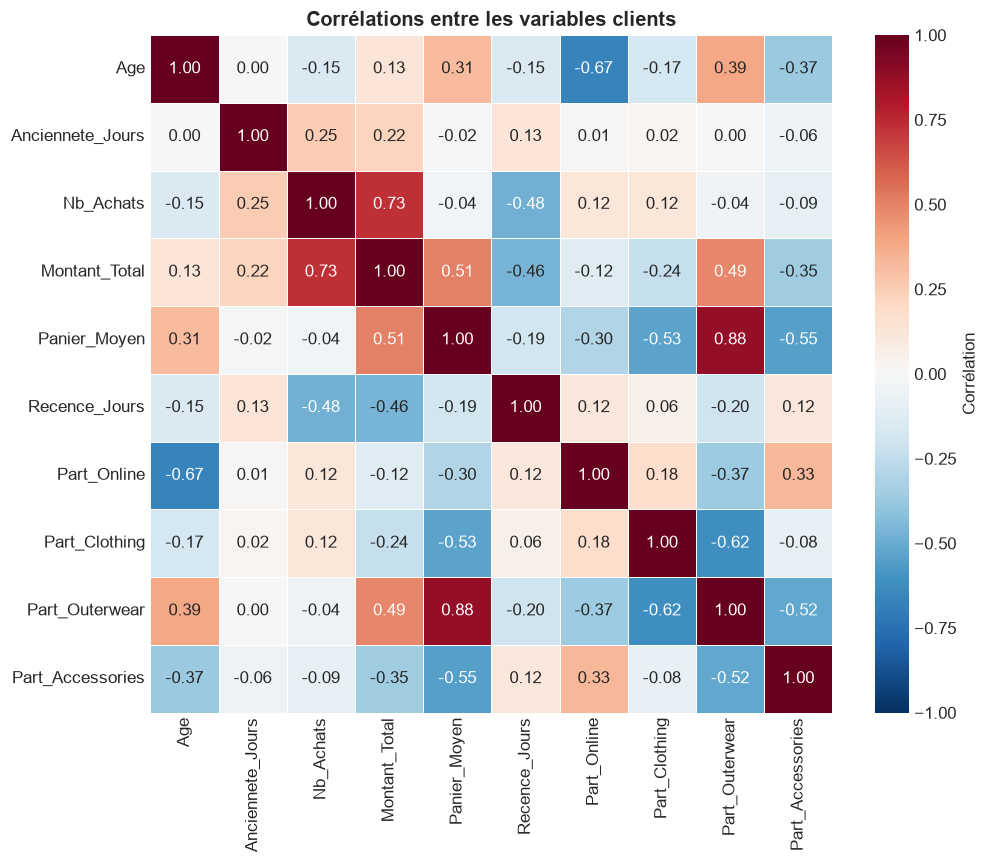

In [16]:
variables = ["Age", "Anciennete_Jours", "Nb_Achats", "Montant_Total", "Panier_Moyen",
             "Recence_Jours", "Part_Online", "Part_Clothing", "Part_Outerwear", "Part_Accessories"]
corr = acheteurs[variables].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Corrélation"})
ax.set_title("Corrélations entre les variables clients")
sauver(fig, "10_correlations"); plt.show()

**Commentaire.** Quelques relations ressortent nettement :
- l'âge est fortement lié négativement à la part d'achats en ligne : plus le client est âgé, moins il achète en ligne ;
- le panier moyen est très lié à la part d'Outerwear : les clients qui achètent des manteaux et des vestes ont les paniers les plus élevés ;
- le nombre d'achats et le montant total évoluent ensemble, ce qui est logique ;
- la récence est liée négativement au nombre d'achats : les clients qui achètent souvent sont aussi ceux qui ont acheté récemment ;
- les parts de catégories s'opposent entre elles, puisqu'elles se partagent 100 % des dépenses.

Pour la segmentation, les variables très corrélées (Nb_Achats et Montant_Total par exemple) apportent une information en partie redondante ; la PCA permettra d'en tenir compte. Rappel : une corrélation n'est pas une relation de cause à effet.

## 8. Aperçu des campagnes

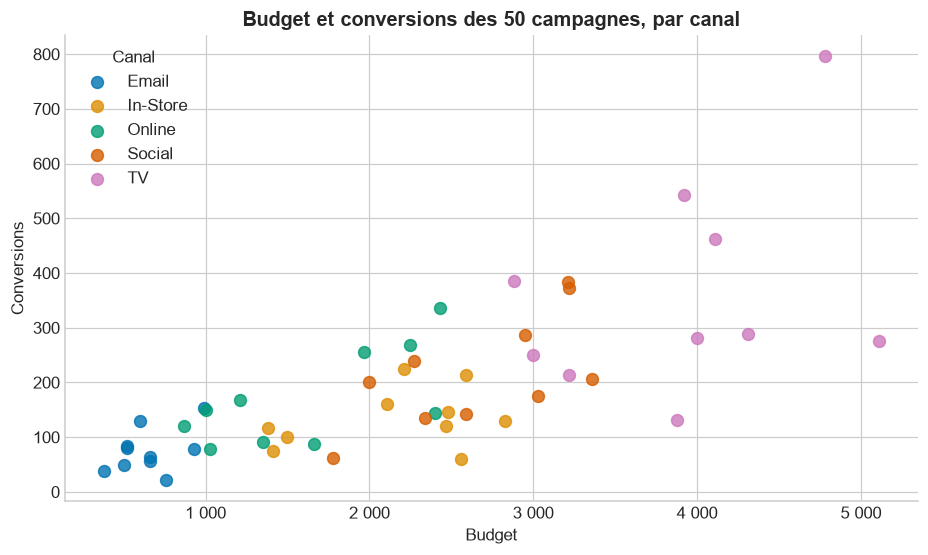

In [17]:
fig, ax = plt.subplots()
for (canal, g), couleur in zip(campagnes.groupby("Channel"), PALETTE):
    ax.scatter(g["Budget"], g["Conversions"], label=canal, color=couleur, s=60, alpha=0.8)
ax.set_title("Budget et conversions des 50 campagnes, par canal")
ax.set_xlabel("Budget"); ax.set_ylabel("Conversions"); ax.legend(title="Canal")
ax.xaxis.set_major_formatter(euros)
sauver(fig, "11_campagnes_budget_conversions"); plt.show()

**Commentaire.** Les conversions augmentent avec le budget, mais pas au même rythme selon le canal : pour un même budget, certains canaux convertissent nettement plus que d'autres. Les campagnes TV sont les plus chères, les campagnes Email les moins chères. L'analyse détaillée de la rentabilité (CTR, CPC, CPA, ROI) est réalisée dans M5.

## 9. Synthèse

- **Données** : 805 clients, 5 337 ventes sur 2023-2024, 20 produits, 50 campagnes. Aucune valeur manquante en dehors des clients sans achat.
- **Clients** : tous les âges sont représentés (18 à 70 ans). Le genre et la ville sont répartis de façon équilibrée et différencient peu les clients.
- **Valeur** : les dépenses sont très inégales entre clients ; une minorité de gros clients pèse lourd.
- **Produits** : Outerwear fait environ la moitié du chiffre d'affaires avec des produits chers ; Clothing est la catégorie la plus vendue en nombre.
- **Canaux** : Online fait plus de ventes, le magasin des paniers plus élevés ; chiffre d'affaires comparable.
- **Âge et canal** : lien très fort, les jeunes achètent en ligne et les plus âgés en magasin.
- **Temps** : pic net en novembre-décembre chaque année.
- **Churn** : près de la moitié des acheteurs n'ont pas acheté depuis plus de 3 mois.

**Pour la suite :**
- M3 (Miora) : utiliser les variables de comportement plutôt que le genre et la ville ; normaliser les montants.
- M6 (Câline) : la récence confirme qu'il y a assez de clients inactifs pour entraîner un modèle de churn.
- M7 (Lalatiana) : adapter le canal à l'âge du segment et concentrer l'effort sur novembre-décembre.